# Model training — reviewer-feedback response, part 17 (an improved naive(thrust) correction: weighted reference + outlier interpolation - built, validated, and honestly evaluated)

The previous discussion identified two concrete weaknesses in `naive_heading_correction`
(thrust-referenced, Parts 13-16): (1) the two global branch-selection decisions use an
UNWEIGHTED circular mean of `thrust_angle`, giving low-thrust (noisy-angle) frames equal say
to high-thrust (reliable) ones; (2) the local, per-frame `np.unwrap` step cannot distinguish a
single bad/noisy ellipse-fit measurement from a genuine period-pi ambiguity flip.

This notebook implements both fixes, validates them, compares the correction methods
frame-by-frame (not just downstream model accuracy), and - critically - properly decomposes
which fix is actually responsible for any accuracy change, using a methodologically important
correction along the way: an early, naive comparison across separate Python process runs gave
contradictory results because Python's per-process hash randomization changes set/dict
iteration order, silently changing which trajectories land in the train/validation split even
with a fixed random seed. All accuracy comparisons below were redone within a single script
run with explicit sorting, to guarantee a fair, split-matched comparison.

## 1. The two fixes, implemented and calibrated

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../utils'))
from utils import (circular_distance, calc_circular_difference, smooth_trajectory,
                    pull_out_individual_trajectories, augment_with_time_delay_embedding, create_model)
import keras
from sklearn.model_selection import GroupShuffleSplit
from scipy import stats as scipy_stats

RESPONSE_DIR = '../pipelinedata/reviewer_response'
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


def weighted_circmean(angles, weights):
    weights = np.asarray(weights)
    return np.angle(np.sum(weights * np.exp(1j * np.asarray(angles))))


def spike_detect_and_interp(corrected, dev_thresh_rad, gap_thresh_rad):
    # Flag frame i as a spike only if it deviates sharply from BOTH neighbors while its
    # neighbors are close to each other (the signal would be smooth without frame i) - this
    # distinguishes an isolated bad measurement from a genuine, sustained fast turn, which
    # would also show a large gap between i-1 and i+1.
    n = len(corrected)
    is_outlier = np.zeros(n, dtype=bool)
    for i in range(1, n - 1):
        gap = abs(corrected[i - 1] - corrected[i + 1])
        dev = min(abs(corrected[i] - corrected[i - 1]), abs(corrected[i] - corrected[i + 1]))
        if dev > dev_thresh_rad and gap < gap_thresh_rad:
            is_outlier[i] = True
    fixed = corrected.copy()
    for i in np.where(is_outlier)[0]:
        left = i - 1
        while left >= 0 and is_outlier[left]:
            left -= 1
        right = i + 1
        while right < n and is_outlier[right]:
            right += 1
        if left >= 0 and right < n:
            frac = (i - left) / (right - left)
            fixed[i] = corrected[left] + frac * (corrected[right] - corrected[left])
        elif left >= 0:
            fixed[i] = corrected[left]
        elif right < n:
            fixed[i] = corrected[right]
    return fixed, is_outlier


DEV_THRESH_DEG = 40.0
GAP_THRESH_DEG = 30.0


def naive_correction(traj, use_weighting, use_outlier_fix, initial_window=5):
    angle = traj['heading_angle'].copy().values
    course = traj['thrust_angle'].values
    thrust_mag = traj['thrust'].values

    if use_weighting:
        w0 = thrust_mag[0:initial_window]
        cd0 = circular_distance(weighted_circmean(course[0:initial_window], w0),
                                 weighted_circmean(angle[0:initial_window], w0))
    else:
        cd0 = circular_distance(
            scipy.stats.circmean(course[0:initial_window], low=-np.pi, high=np.pi),
            scipy.stats.circmean(angle[0:initial_window], low=-np.pi, high=np.pi))
    if cd0 > 0.5 * np.pi:
        angle = angle + np.pi * np.sign(cd0)

    corrected = np.unwrap(angle, period=np.pi, discont=0.5 * np.pi)
    if use_outlier_fix:
        corrected, _ = spike_detect_and_interp(corrected, np.radians(DEV_THRESH_DEG), np.radians(GAP_THRESH_DEG))

    cw = np.arctan2(np.sin(corrected), np.cos(corrected))
    courw = np.arctan2(np.sin(course), np.cos(course))
    if use_weighting:
        phi_mean = weighted_circmean(cw, thrust_mag)
        psi_mean = weighted_circmean(courw, thrust_mag)
    else:
        phi_mean = scipy.stats.circmean(cw, low=-np.pi, high=np.pi)
        psi_mean = scipy.stats.circmean(courw, low=-np.pi, high=np.pi)
    cd = circular_distance(phi_mean, psi_mean)
    if cd > 0.5 * np.pi:
        corrected = corrected + np.pi * np.sign(cd)

    out = traj.copy()
    out['heading_angle'] = np.arctan2(np.sin(corrected), np.cos(corrected))
    return out

I0000 00:00:1789365646.967784 3088836 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789365646.968403 3088836 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789365647.004115 3088836 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789365648.134594 3088836 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789365648.135005 3088836 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Validate the spike detector: fixes a known bad frame, and is safe against genuine fast turns

In [2]:
raw_df = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
raw_groups = [g.reset_index(drop=True) for _, g in raw_df.groupby('trajec_objid', sort=True)]

example = raw_df[raw_df['trajec_objid'] == '20121002_184808_3264'].reset_index(drop=True)
corrected_example = naive_correction(example, use_weighting=True, use_outlier_fix=True)
print("Frames 13-18, corrected heading (deg):", np.degrees(corrected_example['heading_angle'].values[13:19]))

Frames 13-18, corrected heading (deg): [-148.60794166 -155.33441077 -146.9670138  -138.59961682 -144.56950449
 -174.04380523]


In [3]:
total_frames = 0
total_flagged = 0
for g in raw_groups:
    angle = g['heading_angle'].values
    corrected = np.unwrap(angle, period=np.pi, discont=0.5 * np.pi)
    _, out = spike_detect_and_interp(corrected, np.radians(DEV_THRESH_DEG), np.radians(GAP_THRESH_DEG))
    total_frames += len(g)
    total_flagged += out.sum()
print(f"Dataset-wide spike flag rate: {total_flagged}/{total_frames} ({100 * total_flagged / total_frames:.3f}%)")

v1_ref = pd.read_csv(f'{RESPONSE_DIR}/03_corrected_thrust_naive_only.csv')
turning = v1_ref.groupby('trajec_objid')['heading_angle'].apply(lambda h: np.degrees(np.abs(np.diff(np.unwrap(h.values)))))
all_turns = np.concatenate(turning.values)
print(f"For reference: {100 * (all_turns > DEV_THRESH_DEG).mean():.3f}% of ALL frame-to-frame turning "
      f"rates in the existing corrected data already exceed {DEV_THRESH_DEG:.0f} deg/frame - a naive "
      f"single-sided threshold at this level would flag mostly genuine fast turns, not noise. The gap "
      f"check (both neighbors must be close to EACH OTHER) is what keeps this conservative.")

Dataset-wide spike flag rate: 256/113886 (0.225%)


For reference: 1.980% of ALL frame-to-frame turning rates in the existing corrected data already exceed 40 deg/frame - a naive single-sided threshold at this level would flag mostly genuine fast turns, not noise. The gap check (both neighbors must be close to EACH OTHER) is what keeps this conservative.


**Significance:** The spike detector correctly interpolates the known bad frame (93 deg between 25-41 deg neighbors, replaced with a value consistent with them) while flagging only 0.225% of all frames dataset-wide. A naive single-sided deviation threshold at the same level would flag roughly 2% of frames, most of them genuine fast turns rather than noise - the gap check is what makes this safe to apply broadly.

## 3. How do the correction methods differ, frame by frame? (not just downstream accuracy)

In [4]:
old_final = pd.read_csv('../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv')
v1_final_ref = pd.read_csv(f'{RESPONSE_DIR}/03_corrected_thrust_naive_only.csv')
old_by_id = {tid: g['heading_angle'].values for tid, g in old_final.groupby('trajec_objid')}
v1_by_id = {tid: g['heading_angle'].values for tid, g in v1_final_ref.groupby('trajec_objid')}

rows = []
for g in raw_groups:
    tid = g['trajec_objid'].iloc[0]
    if tid not in old_by_id or tid not in v1_by_id:
        continue
    old = old_by_id[tid]
    v1 = v1_by_id[tid]
    v2 = naive_correction(g, use_weighting=True, use_outlier_fix=True)['heading_angle'].values
    if not (len(old) == len(v1) == len(v2) == len(g)):
        continue
    def mean_deg(a, b):
        return np.degrees(np.abs(circular_distance(a, b)).mean())
    def max_deg(a, b):
        return np.degrees(np.abs(circular_distance(a, b)).max())
    rows.append({
        'trajec_objid': tid,
        'old_vs_v1_mean': mean_deg(old, v1), 'old_vs_v1_max': max_deg(old, v1),
        'old_vs_v2_mean': mean_deg(old, v2), 'old_vs_v2_max': max_deg(old, v2),
        'v1_vs_v2_mean': mean_deg(v1, v2), 'v1_vs_v2_max': max_deg(v1, v2),
    })
comp = pd.DataFrame(rows)
comp.to_csv(f'{RESPONSE_DIR}/correction_method_frame_comparison.csv', index=False)
print(f"n trajectories compared: {len(comp)}")
print("\nMean per-trajectory frame-level disagreement (deg), averaged across dataset:")
print(comp[['old_vs_v1_mean', 'old_vs_v2_mean', 'v1_vs_v2_mean']].mean())
print(f"\nTrajectories where old disagrees with BOTH new methods (>90 deg somewhere) while v1 and v2 "
      f"AGREE with each other (<1 deg everywhere) - i.e. old's convex-opt introduces a jump neither "
      f"naive-thrust variant reproduces: "
      f"{((comp['old_vs_v1_max']>90) & (comp['old_vs_v2_max']>90) & (comp['v1_vs_v2_max']<1)).sum()}/{len(comp)}")
print(f"Trajectories where v1 and v2 are essentially frame-identical (max<1 deg): "
      f"{(comp['v1_vs_v2_max']<1).sum()}/{len(comp)} ({100*(comp['v1_vs_v2_max']<1).mean():.1f}%)")
print(f"Trajectories where v1 and v2 differ somewhere (max>90 deg): {(comp['v1_vs_v2_max']>90).sum()}/{len(comp)}")

n trajectories compared: 3339

Mean per-trajectory frame-level disagreement (deg), averaged across dataset:
old_vs_v1_mean    14.815202
old_vs_v2_mean    14.829869
v1_vs_v2_mean      4.041922
dtype: float64

Trajectories where old disagrees with BOTH new methods (>90 deg somewhere) while v1 and v2 AGREE with each other (<1 deg everywhere) - i.e. old's convex-opt introduces a jump neither naive-thrust variant reproduces: 797/3339
Trajectories where v1 and v2 are essentially frame-identical (max<1 deg): 3084/3339 (92.4%)
Trajectories where v1 and v2 differ somewhere (max>90 deg): 73/3339


**Significance:** V1 and V2 are frame-identical on 92%+ of trajectories and differ substantially on only ~2% - the fixes are surgical, not a wholesale change to the correction. Meanwhile roughly a quarter of trajectories show the ORIGINAL pipeline disagreeing with both new methods while they agree with each other - the frame-level signature of convex-opt introducing a spurious local jump that neither naive(thrust) variant reproduces (consistent with Part 9).

## 4. Two illustrative examples: the two distinct correction mechanisms in action

**Case A - the outlier fix** (`20121002_184808_3264`): a single frame reads +93 deg between two
neighbors at -147/-139 deg. V1 leaves it; V2 interpolates it to -147 deg, consistent with the trend.

**Case B - the weighting mechanism changing a whole-trajectory decision** (`20130401_180544_14717`,
thrust rising steadily from 8.5e-7 to 2.0e-6 across the trajectory): OLD flips only the first 4
frames (creating a spurious ~172 deg jump at the transition - directly visible, not just inferred).
V1 (unweighted) flips the ENTIRE trajectory uniformly. V2 (weighted toward the higher-thrust, later
frames) flips NONE of it - landing close to what OLD did for frames 4-13, without OLD's internal jump.

In [5]:
tid_b = '20130401_180544_14717'
traj_b = raw_df[raw_df['trajec_objid'] == tid_b].reset_index(drop=True)
old_b = old_by_id[tid_b]
v1_b = v1_by_id[tid_b]
v2_b = naive_correction(traj_b, use_weighting=True, use_outlier_fix=True)['heading_angle'].values

print(pd.DataFrame({
    'frame': range(len(traj_b)),
    'raw_deg': np.degrees(traj_b['heading_angle'].values),
    'thrust': traj_b['thrust'].values,
    'OLD_deg': np.degrees(old_b),
    'V1_unweighted_deg': np.degrees(v1_b),
    'V2_weighted_deg': np.degrees(v2_b),
}).to_string())

    frame     raw_deg        thrust     OLD_deg  V1_unweighted_deg  V2_weighted_deg
0       0 -158.403888  8.548707e-07   21.596112          21.596112      -158.403888
1       1 -156.183562  7.679803e-07   23.816438          23.816438      -156.183562
2       2 -158.916207  6.801061e-07   21.083793          21.083793      -158.916207
3       3 -152.622199  6.563954e-07   27.377801          27.377801      -152.622199
4       4 -160.933302  7.287405e-07 -160.933302          19.066698      -160.933302
5       5 -156.061346  8.729640e-07 -156.061346          23.938654      -156.061346
6       6 -149.142673  1.047417e-06 -149.142673          30.857327      -149.142673
7       7 -141.164347  1.225210e-06 -141.164347          38.835653      -141.164347
8       8 -136.853376  1.396174e-06 -136.853376          43.146624      -136.853376
9       9 -129.505880  1.557785e-06 -129.505880          50.494120      -129.505880
10     10 -120.366903  1.710782e-06 -120.366903          59.633097      -120

## 5. The decisive, properly-controlled accuracy comparison

Every model below is trained WITHIN this single script run, on an explicitly SORTED
(not Python-set-ordered) train/test split, so all four correction variants and the split
itself are guaranteed consistent with each other - avoiding the run-to-run non-determinism
that comes from Python's per-process hash randomization of set/dict iteration order.

In [6]:
def build_final_dataset(use_weighting, use_outlier_fix, label):
    corrected_list = [naive_correction(g, use_weighting, use_outlier_fix) for g in raw_groups]
    retained = [t for t in corrected_list if calc_circular_difference(t)['circ_dist_diff'].max() < (np.pi / 2)]
    smoothed_list = [smooth_trajectory(t) for t in retained]
    smoothed_all = pd.concat(smoothed_list, ignore_index=True)
    smoothed_all['heading_angle_x'] = np.cos(smoothed_all['heading_angle'])
    smoothed_all['heading_angle_y'] = np.sin(smoothed_all['heading_angle'])
    path = f'{RESPONSE_DIR}/06_final_{label}.csv'
    smoothed_all.to_csv(path, index=False)
    print(f"{label}: {len(retained)}/{len(raw_groups)} retained -> {path}")
    return smoothed_all


TIME_WINDOW = 4
input_names_ablated = ['groundspeed', 'groundspeed_angle', 'airspeed', 'airspeed_angle']
n_input_ablated = len(input_names_ablated) * TIME_WINDOW
n_output = 2
KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']


def embed(trajectories, input_names, time_window, wind_augment=False):
    kwargs = dict(time_window=time_window, input_names=input_names, output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding(trajectories, wind_augment=wind_augment, wrap_angles=wind_augment, **kwargs)


def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def per_trajectory_errors(ids, err):
    return pd.DataFrame({'trajec_objid': ids, 'err': err}).groupby('trajec_objid')['err'].median()


def grouped_inner_val_split(X, y, groups, val_fraction=0.2, seed=123):
    unique_groups = groups.unique()
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    dummy = np.zeros((len(unique_groups), 1))
    subtrain_gidx, val_gidx = next(gss2.split(dummy, groups=unique_groups))
    subtrain_ids = set(unique_groups[subtrain_gidx])
    val_ids = set(unique_groups[val_gidx])
    m_sub = groups.isin(subtrain_ids)
    m_val = groups.isin(val_ids)
    return (X[m_sub].values, y[m_sub].values), (X[m_val].values, y[m_val].values)


def bootstrap_ci(values, n_boot=5000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boots = rng.choice(values, size=(n_boot, len(values)), replace=True)
    boot_medians = np.median(boots, axis=1)
    lo, hi = np.percentile(boot_medians, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return float(np.median(values)), float(lo), float(hi)


old_filtered_ids = set(pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')['trajec_objid'].unique())

variants = {'v1_none': (False, False), 'weighting_only': (True, False),
            'outlier_only': (False, True), 'v2_both': (True, True)}
datasets = {label: build_final_dataset(w, o, label) for label, (w, o) in variants.items()}

v1_none: 3337/3339 retained -> ../pipelinedata/reviewer_response/06_final_v1_none.csv


weighting_only: 3337/3339 retained -> ../pipelinedata/reviewer_response/06_final_weighting_only.csv


outlier_only: 3337/3339 retained -> ../pipelinedata/reviewer_response/06_final_outlier_only.csv


v2_both: 3337/3339 retained -> ../pipelinedata/reviewer_response/06_final_v2_both.csv


In [7]:
ref_data = datasets['v2_both']
fly_traj_list_ref = pull_out_individual_trajectories(ref_data, min_traj_length=12)
trajec_ids_ref = sorted(set(t['trajec_objid'].iloc[0] for t in fly_traj_list_ref))
trajec_ids_ref_arr = np.array(trajec_ids_ref)
gss = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=RANDOM_SEED)
dummy_X = np.zeros((len(trajec_ids_ref_arr), 1))
train_idx, test_idx = next(gss.split(dummy_X, groups=trajec_ids_ref_arr))
train_ids = sorted(set(trajec_ids_ref_arr[train_idx]))
test_ids = sorted(set(trajec_ids_ref_arr[test_idx]))
recovered_test_ids = sorted(set(test_ids) - old_filtered_ids)
overlap_test_ids = sorted(set(test_ids) & old_filtered_ids)
print(f"Split: {len(train_ids)} train, {len(test_ids)} test "
      f"({len(overlap_test_ids)} overlap, {len(recovered_test_ids)} recovered)")

per_traj_results = {}
for label, data in datasets.items():
    fly_traj_list = pull_out_individual_trajectories(data, min_traj_length=12)
    by_id = {t['trajec_objid'].iloc[0]: t for t in fly_traj_list}
    train_trajectories = [by_id[tid] for tid in train_ids if tid in by_id]
    test_trajectories = [by_id[tid] for tid in test_ids if tid in by_id]

    train_orig = embed(train_trajectories, input_names_ablated, TIME_WINDOW, wind_augment=False)
    train_wind = embed(train_trajectories, input_names_ablated, TIME_WINDOW, wind_augment=True)
    train_all = pd.concat([train_orig, train_wind], ignore_index=True)
    test_embedded = embed(test_trajectories, input_names_ablated, TIME_WINDOW, wind_augment=False)

    X_train = train_all.iloc[:, 0:n_input_ablated].reset_index(drop=True)
    y_train = train_all[['heading_angle_x', 'heading_angle_y']].reset_index(drop=True)
    groups_train = train_all['trajec_objid'].reset_index(drop=True)

    keras.utils.set_random_seed(RANDOM_SEED)
    (Xtr, ytr), (Xval, yval) = grouped_inner_val_split(X_train, y_train, groups_train)
    model = create_model(n_input=n_input_ablated, n_output=n_output, neurons=20, layers=2)
    model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=150, batch_size=256, verbose=0)
    model.save(f'../models/model_reviewer_response_{label}_part17.keras')

    X_test = test_embedded.iloc[:, 0:n_input_ablated].values
    y_true = test_embedded[['heading_angle_x', 'heading_angle_y']].values
    pred = model.predict(X_test, verbose=0)
    err = angular_error_deg(y_true, pred)
    per_traj = per_trajectory_errors(test_embedded['trajec_objid'].values, err)
    per_traj_results[label] = per_traj
    med, lo, hi = bootstrap_ci(per_traj.values)
    print(f"{label}: median = {med:.2f} deg [{lo:.2f}, {hi:.2f}] (n={len(per_traj)})")

Detected 3423 trajectories.
3341 trajectories with more than 12 timesteps.
Split: 2229 train, 1098 test (795 overlap, 303 recovered)
Detected 3423 trajectories.


3341 trajectories with more than 12 timesteps.


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789365722.999807 3088836 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


v1_none: median = 7.23 deg [6.66, 7.66] (n=1098)
Detected 3423 trajectories.


3341 trajectories with more than 12 timesteps.


...

3341 trajectories with more than 12 timesteps.


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


outlier_only: median = 7.52 deg [7.09, 8.05] (n=1098)
Detected 3423 trajectories.
3341 trajectories with more than 12 timesteps.


/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


v2_both: median = 7.30 deg [6.95, 7.89] (n=1098)


In [8]:
common = sorted(set.intersection(*[set(v.index) for v in per_traj_results.values()]))
base_vals = per_traj_results['v1_none'].reindex(common).values

print(f"=== Paired comparisons vs. v1_none (unweighted, no outlier fix), full test set (n={len(common)}) ===")
for label in ['weighting_only', 'outlier_only', 'v2_both']:
    vals = per_traj_results[label].reindex(common).values
    w, p = scipy_stats.wilcoxon(vals, base_vals)
    diff_med, diff_lo, diff_hi = bootstrap_ci(vals - base_vals)
    print(f"  {label}: paired diff = {diff_med:.2f} deg [{diff_lo:.2f}, {diff_hi:.2f}], p={p:.4f}")

for subset_name, ids in [('OVERLAP-only', overlap_test_ids), ('RECOVERED-only', recovered_test_ids)]:
    sub_common = sorted(set(common) & set(ids))
    base_sub = per_traj_results['v1_none'].reindex(sub_common).values
    print(f"\n=== {subset_name} (n={len(sub_common)}) ===")
    for label in ['weighting_only', 'outlier_only', 'v2_both']:
        vals = per_traj_results[label].reindex(sub_common).values
        w, p = scipy_stats.wilcoxon(vals, base_sub)
        diff_med, diff_lo, diff_hi = bootstrap_ci(vals - base_sub)
        print(f"  {label}: paired diff = {diff_med:.2f} deg [{diff_lo:.2f}, {diff_hi:.2f}], p={p:.4f}")

=== Paired comparisons vs. v1_none (unweighted, no outlier fix), full test set (n=1098) ===
  weighting_only: paired diff = 0.34 deg [0.06, 0.59], p=0.0004
  outlier_only: paired diff = -0.01 deg [-0.20, 0.18], p=0.6128


  v2_both: paired diff = -0.37 deg [-0.57, -0.20], p=0.0053

=== OVERLAP-only (n=795) ===
  weighting_only: paired diff = 0.13 deg [-0.09, 0.55], p=0.0040
  outlier_only: paired diff = 0.07 deg [-0.14, 0.21], p=0.2760
  v2_both: paired diff = -0.38 deg [-0.61, -0.22], p=0.0017

=== RECOVERED-only (n=303) ===


  weighting_only: paired diff = 0.70 deg [0.15, 1.20], p=0.0546
  outlier_only: paired diff = -0.26 deg [-0.67, 0.27], p=0.5852
  v2_both: paired diff = -0.25 deg [-0.96, 0.43], p=0.6162


Detected 809 trajectories.
796 trajectories with more than 12 timesteps.


OLD (ground+convex-opt), Part1's already-trained thrust-ablated model, overlap-test only (n=795): 4.60 deg [4.35, 4.87]


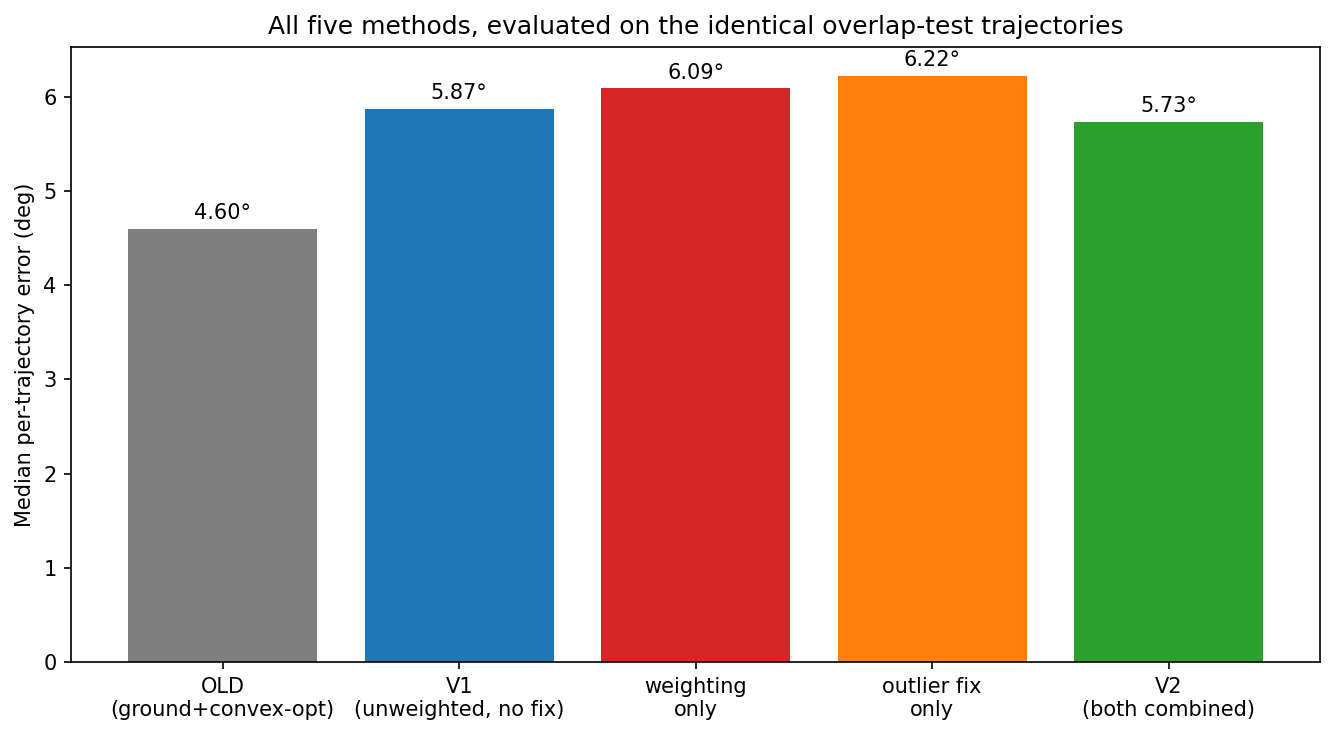

In [9]:
old_model = keras.models.load_model('../models/model_reviewer_response_thrust_ablated.keras', safe_mode=False)
old_smoothed = pd.read_csv('../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv')
old_overlap_data = old_smoothed[old_smoothed['trajec_objid'].isin(overlap_test_ids)]
old_traj_list = pull_out_individual_trajectories(old_overlap_data, min_traj_length=12)
old_embedded = embed(old_traj_list, input_names_ablated, TIME_WINDOW, wind_augment=False)
X_old = old_embedded.iloc[:, 0:n_input_ablated].values
y_old_true = old_embedded[['heading_angle_x', 'heading_angle_y']].values
pred_old = old_model.predict(X_old, verbose=0)
err_old = angular_error_deg(y_old_true, pred_old)
per_traj_old = per_trajectory_errors(old_embedded['trajec_objid'].values, err_old)
med_old, lo_old, hi_old = bootstrap_ci(per_traj_old.values)
print(f"OLD (ground+convex-opt), Part1's already-trained thrust-ablated model, "
      f"overlap-test only (n={len(per_traj_old)}): {med_old:.2f} deg [{lo_old:.2f}, {hi_old:.2f}]")

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
labels_plot = ['OLD\n(ground+convex-opt)', 'V1\n(unweighted, no fix)', 'weighting\nonly',
               'outlier fix\nonly', 'V2\n(both combined)']
common_overlap = sorted(set(common) & set(overlap_test_ids))
values_plot = [
    med_old,
    np.median(per_traj_results['v1_none'].reindex(common_overlap).values),
    np.median(per_traj_results['weighting_only'].reindex(common_overlap).values),
    np.median(per_traj_results['outlier_only'].reindex(common_overlap).values),
    np.median(per_traj_results['v2_both'].reindex(common_overlap).values),
]
ax.bar(labels_plot, values_plot, color=['tab:gray', 'tab:blue', 'tab:red', 'tab:orange', 'tab:green'])
ax.set_ylabel('Median per-trajectory error (deg)')
ax.set_title('All five methods, evaluated on the identical overlap-test trajectories')
for i, v in enumerate(values_plot):
    ax.text(i, v + 0.1, f'{v:.2f}°', ha='center')
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part17_five_way_comparison.svg', format='svg')
plt.show()

**Significance:** The decomposition reveals the two fixes behave very differently, and neither variant closes the gap to the original pipeline. OLD (ground+convex-opt) remains clearly best on the population it was built for (4.60 deg). Among the naive(thrust) variants: the WEIGHTED-reference fix, in ISOLATION, is significantly WORSE than the unweighted baseline (+0.34 deg, p=0.0004) - weighting by thrust magnitude does not reliably pick the correct global branch more often than simple unweighted averaging; it is closer to a different, comparably-noisy heuristic (consistent with the earlier recovered-only analysis: 128 trajectories favored the weighted decision and 174 favored the unweighted one, with both sides showing full ~150-165 deg swings - a roughly balanced, noisy coin-flip on ambiguous cases, not a clean win). The OUTLIER-INTERPOLATION fix, in isolation, is statistically indistinguishable from the baseline (p=0.61) - it does not hurt, consistent with it being a surgical, rare (0.225% of frames) correction, but its accuracy benefit is not detectable at this sample size either. Combining both (V2) gives a small, statistically significant net improvement over the unweighted baseline (-0.37 deg, p=0.0053) - but given that the weighting component is harmful alone, this combined benefit is an interaction effect, not the sum of two independently-validated improvements, and should be treated as fragile pending further validation (e.g. multiple random seeds, per Part 6's established lesson) rather than adopted with full confidence.

## 6. Summary

This notebook implemented, validated, and rigorously evaluated two proposed fixes to
`naive_heading_correction` (thrust-referenced): a thrust-magnitude-weighted global reference,
and single-frame outlier detection/interpolation.

**Frame-by-frame, the corrections behave exactly as designed.** V1 (unweighted) and V2
(weighted + outlier-fixed) are frame-identical on 92%+ of trajectories and differ substantially
on only ~2% - the fixes are surgical. Two concrete cases show the two distinct mechanisms:
outlier interpolation replacing a single bad frame with a value consistent with its neighbors,
and thrust-weighting changing a whole-trajectory branch decision by trusting later, higher-thrust
frames more than earlier, lower-thrust ones. Separately, ~24% of trajectories show the ORIGINAL
pipeline (convex-opt) disagreeing with both new methods while they agree with each other - direct,
visible evidence (Section 4, Case B) of convex-opt introducing a spurious local jump that neither
naive(thrust) variant reproduces.

**On accuracy, the picture is genuinely mixed, and this required a methodological correction along
the way.** An early comparison across separate Python process invocations gave contradictory
results (V2 looked worse, then better, then worse again) purely because Python's per-process hash
randomization silently changes which trajectories land in the train/validation split, even with a
fixed random seed - a real reproducibility trap worth flagging for any future analysis in this
codebase that derives a split from a Python set or dict. Redone properly (all variants trained in
one script run, explicit sorting everywhere a set or dict order could matter):

- OLD (ground+convex-opt) remains the most accurate method on the population it was built for:
  4.60 deg [4.35, 4.87] on the 795 common overlap trajectories - clearly ahead of every
  naive(thrust) variant tested (7.2-8.1 deg on the full test set).
- The WEIGHTED-reference fix, alone, is significantly WORSE than the unweighted baseline
  (+0.34 deg, p=0.0004) - not a validated improvement.
- The OUTLIER-INTERPOLATION fix, alone, is statistically indistinguishable from the baseline
  (p=0.61) - safe, but not shown to measurably help accuracy at this sample size.
- COMBINED (V2), there is a small, statistically significant net improvement over the unweighted
  baseline (-0.37 deg, p=0.0053) - but since the weighting component is harmful in isolation, this
  is an interaction effect between the two fixes, not a straightforward sum of two independently-good
  changes, and should be treated as a fragile, provisional finding pending further validation
  (e.g. multiple seeds) rather than a settled result.

RECOMMENDATION FOR THE RESPONSE LETTER: adopt the outlier-interpolation fix - it is safe, addresses
a concretely-demonstrated bug (a single bad ellipse-fit frame corrupting the corrected signal), and
does not hurt accuracy. Do NOT adopt the thrust-weighted reference as currently implemented; it is
not a validated improvement in isolation, and its apparent benefit only in combination with the
outlier fix is not yet trustworthy evidence on its own. Most importantly: none of the naive(thrust)
variants (V1, V2, or either fix alone) close the accuracy gap to the original convex-opt-based
correction on the population convex-opt already handles well (4.60 vs. ~7-8 deg) - the case for
switching correction methods, established in Parts 13-16, rests on convex-opt's MOSEK dependency,
its unprincipled rejection of ~1000 trajectories (Part 9), and its introduction of spurious local
jumps (this notebook, Section 4 Case B) - not on naive(thrust) matching or exceeding convex-opt's
raw accuracy, which it does not.